# HLS and MODIS Comparison
---
**Summary**
The following code compiles the data from MODIS and HLS into their own respective DataFrames that contain a row for each composite as well as the vegatation index mean, median, min, max, standard deviation, and valid pixels. These DataFrames are then used to create figures comparing the two, including a vegetation index time series, a graph of the vegetation index multi-year seasonal means, and an annual phenology summary that shows the annual min, max, start of season (calculated as the first DOY to reach the greenup threshold, 15% amplitude), end of season (first DOY to fall below threshold after peak), and season length.

## Preparing the Data

In [1]:
# Import packages
import os
import re
import gc
import h5py
import math
import folium
import rasterio
import numpy as np
import pandas as pd
import xarray as xr
import rioxarray as rxr
import geopandas as gpd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
from rasterio.mask import mask as rio_mask
from shapely.ops import unary_union, linemerge, polygonize

import matplotlib.cm as cm
from matplotlib import colors
from matplotlib import dates, colors
from matplotlib.colors import Normalize
from matplotlib.colors import ListedColormap

from shapely.geometry import box
from shapely.geometry import Point
from shapely.geometry import shape

import boto3
from botocore import UNSIGNED
from botocore.client import Config

import glob
from scipy import stats
from rasterio.transform import array_bounds

In [2]:
# Initialize variables
veg_index = "evi"
tile_id = "12TYP"
output_dir = f"hls_modis_comparisons/{tile_id}"
os.makedirs(output_dir, exist_ok=True)
start_year = 2016
end_year = 2025

# Store composite data to use for spatial statistics
all_composites_hls = []
all_composites_modis = []

In [3]:
def compute_hls_vi_stats(veg_index, data_dir, outdir,
                         tile_id, start_year=None, end_year=None,
                         roi_shp=None, roi_name=None):
    vi_pattern = re.compile(
        rf'^{re.escape(tile_id)}_10day_median_(\d{{7}})\_{veg_index.upper()}.tif$',
        re.IGNORECASE
    )
    doy_pattern = re.compile(
        rf'^{re.escape(tile_id)}_DOY_10day_(\d{{7}})\.tif$',
        re.IGNORECASE
    )

    vi_files  = {}
    doy_files = {}

    for fname in os.listdir(data_dir):
        m = vi_pattern.match(fname)
        if m:
            vi_files[m.group(1)] = os.path.join(data_dir, fname)
            continue
        m = doy_pattern.match(fname)
        if m:
            doy_files[m.group(1)] = os.path.join(data_dir, fname)

    years = sorted(set(k[:4] for k in vi_files))
    years = [y for y in years if
             (start_year is None or int(y) >= start_year) and
             (end_year   is None or int(y) <= end_year)]

    if not years:
        print(f"No data found for year range {start_year}–{end_year}")
        return pd.DataFrame()

    print(f"Processing {len(years)} year(s): {years[0]}–{years[-1]}")
    
    roi = None
    if roi_shp is not None:
        if Path(roi_shp).suffix == ".zip":
            roi = gpd.read_file(f"zip://{roi_shp}")
        else:
            roi = gpd.read_file(roi_shp)
        print(f"ROI loaded: {roi_shp}  ({len(roi)} feature(s))")
        if "LineString" in roi.geom_type.values:
            print("Shapefile contains LineStrings, merging into a Polygon.")
            # Create a polygon from the LineStrings
            boundary = linemerge(unary_union(roi.geometry))
            polys = list(polygonize(boundary))
            
            # Redefine the roi using the polygon
            roi = gpd.GeoDataFrame(
                geometry=polys,
                crs=roi.crs
            )

    records = []
    
    for year in years:
        year_keys       = sorted(k for k in vi_files if k[:4] == year)
        print(f"year_keys, {year_keys}")
        annual_vi_stack = []

        for doy_key in year_keys:
            vi_path  = vi_files[doy_key]
            doy_path = doy_files.get(doy_key)
            year_int   = int(doy_key[:4])
            doy_start  = int(doy_key[4:])
            start_date = datetime(year_int, 1, 1) + timedelta(days=doy_start - 1)

            vi = rxr.open_rasterio(vi_path, masked=True, chunks="auto").squeeze("band", drop=True)
            vi.attrs.pop("scale_factor", None)
            vi.attrs.pop("add_offset",   None)

            roi_reproj = None
            if roi is not None:
                roi_reproj = roi.to_crs(vi.rio.crs)
                vi = vi.rio.clip(roi_reproj.geometry, roi_reproj.crs, drop=True)

            if doy_path:
                doy_da = rxr.open_rasterio(doy_path, masked=True).squeeze("band", drop=True)
                doy_da = doy_da.where(vi.notnull())
                doy_da = doy_da.where(doy_da <= 9)

                mean_doy_offset = float(doy_da.mean(skipna=True).values)
                if np.isnan(mean_doy_offset):
                    print(f"Warning: No valid DOY pixels for {doy_key}, using start date")
                    mean_doy_offset = 0.0
                rep_date = start_date + timedelta(days=round(mean_doy_offset))
                # Make sure the date doesn't cross into the next year for graphing purposes
                if rep_date.year != year_int:
                    rep_date = start_date
            else:
                print(f"Warning: No DOY tif for {doy_key}, using start date")
                mean_doy_offset = 0.0
                rep_date        = start_date

            valid = vi.values[~np.isnan(vi.values)]
            if valid.size == 0:
                print(f"Warning: No valid VI pixels for {doy_key} — skipping")
                # Store the crs in case the vi deleted is the last one before the annual
                vi_crs = vi.rio.crs
                del vi
                gc.collect()
                continue

            try:
                all_composites_hls.append(vi.assign_coords(time=rep_date).expand_dims("time"))
            except UnboundLocalError:
                pass
            
            records.append({
                "doy_key":             int(doy_key),
                "composite_start":     start_date,
                "composite_mean_date": rep_date,
                "mean_doy_offset":     round(mean_doy_offset, 2),
                f"{veg_index}_mean":   float(np.mean(valid)),
                f"{veg_index}_median": float(np.median(valid)),
                f"{veg_index}_min":    float(np.min(valid)),
                f"{veg_index}_max":    float(np.max(valid)),
                f"{veg_index}_stdev":  float(np.std(valid, ddof=1)),
                "n_valid_pixels":      int(valid.size),
            })

            annual_vi_stack.append(vi.assign_coords(time=rep_date).expand_dims("time"))

        if not annual_vi_stack:
            print(f"No valid composites for {year} — skipping annual tif")
            continue

        stacked     = xr.concat(annual_vi_stack, dim="time")
        annual_mean = stacked.mean(dim="time", skipna=True)
        annual_std  = stacked.std( dim="time", skipna=True, ddof=1)

        annual_2band = xr.concat(
            [annual_mean.expand_dims("band"),
             annual_std.expand_dims("band")],
            dim="band"
        ).assign_coords(band=[1, 2])

        annual_2band.attrs = {
            "long_name":    [f"{veg_index.upper()}_annual_mean", f"{veg_index.upper()}_annual_stdev"],
            "year":         year,
            "n_composites": len(annual_vi_stack),
        }

        vi_crs = annual_vi_stack[0].rio.crs
        annual_2band = annual_2band.rio.write_crs(vi_crs)

        annual_fname = f"HLS_{tile_id}_{veg_index.upper()}_annual_{year}_{veg_index.upper()}.tif"
        annual_path  = os.path.join(output_dir, annual_fname)
        annual_2band.rio.to_raster(annual_path, compress="lzw")
        print(f"Annual written: {annual_fname}  |  n_composites={len(annual_vi_stack)}")

        del stacked, annual_mean, annual_std, annual_2band, annual_vi_stack
        try:
            del vi
        except UnboundLocalError:
            pass
        gc.collect()
    
    df = pd.DataFrame(records).sort_values("composite_start").reset_index(drop=True)
    if roi_name:
        csv_path = os.path.join(output_dir, f"HLS_{tile_id}_{veg_index.upper()}_timeseries_stats-{roi_name}.csv")
    else:
        csv_path = os.path.join(output_dir, f"HLS_{tile_id}_{veg_index.upper()}_timeseries_stats.csv")
    df.to_csv(csv_path, index=False)
    print(f"Timeseries CSV: {csv_path}")
    return df

In [4]:
def compute_modis_vi_stats(veg_index, data_dir, outdir,
                           tile_id, start_year=None, end_year=None,
                           hls_data_dir=None, roi_shp=None, roi_name=None):

    vi_pattern = re.compile(
        rf'^MOD13Q1_{re.escape(veg_index.upper())}_(\d{{8}})\.tif$',
        re.IGNORECASE
    )
    doy_pattern = re.compile(
        r'^MOD13Q1_DOY_(\d{8})\.tif$',
        re.IGNORECASE
    )

    vi_files  = {}
    doy_files = {}

    for fname in os.listdir(data_dir):
        m = vi_pattern.match(fname)
        if m:
            vi_files[m.group(1)] = os.path.join(data_dir, fname)
            continue
        m = doy_pattern.match(fname)
        if m:
            doy_files[m.group(1)] = os.path.join(data_dir, fname)

    # Filter by year range on the YYYYMMDD key
    vi_files = {k: v for k, v in vi_files.items() if
                (start_year is None or int(k[:4]) >= start_year) and
                (end_year   is None or int(k[:4]) <= end_year)}

    if not vi_files:
        print(f"No data found for year range {start_year}–{end_year}")
        return pd.DataFrame()

    years = sorted(set(k[:4] for k in vi_files))
    years = [y for y in years if
             (start_year is None or int(y) >= start_year) and
             (end_year   is None or int(y) <= end_year)]

    print(f"Processing {len(years)} year(s): {years[0]}–{years[-1]}")

    # Build HLS bounding box to mask to MGRS tile (MODIS has larger footprint)
    hls_bbox_gdf = None
    if hls_data_dir is not None:
        hls_tifs = [
            os.path.join(hls_data_dir, f)
            for f in os.listdir(hls_data_dir)
            if f.lower().endswith(".tif")
        ]
        if hls_tifs:
            sample = rxr.open_rasterio(hls_tifs[0], masked=True)
            hls_crs    = sample.rio.crs
            hls_bounds = sample.rio.bounds()   # (left, bottom, right, top)
            del sample
            gc.collect()

            hls_bbox_geom = box(*hls_bounds)             
            hls_bbox_gdf  = gpd.GeoDataFrame(
                geometry=[hls_bbox_geom], crs=hls_crs
            )
            print(
                f"HLS tile bounds loaded from: {os.path.basename(hls_tifs[0])}\n"
                f"  CRS   : {hls_crs}\n"
                f"  Bounds: left={hls_bounds[0]:.2f}, bottom={hls_bounds[1]:.2f}, "
                f"right={hls_bounds[2]:.2f}, top={hls_bounds[3]:.2f}"
            )
        else:
            print("Warning: hls_data_dir provided but no .tif files found — skipping HLS bounds mask")

    roi = None
    if roi_shp is not None:
        if Path(roi_shp).suffix == ".zip":
            roi = gpd.read_file(f"zip://{roi_shp}")
        else:
            roi = gpd.read_file(roi_shp)
        print(f"ROI loaded: {roi_shp}  ({len(roi)} feature(s))")
        if "LineString" in roi.geom_type.values:
            print("Shapefile contains LineStrings, merging into a Polygon.")
            # Create a polygon from the LineStrings
            boundary = linemerge(unary_union(roi.geometry))
            polys = list(polygonize(boundary))
            
            # Redefine the roi using the polygon
            roi = gpd.GeoDataFrame(
                geometry=polys,
                crs=roi.crs
            )

    records = []

    for year in years:
        print(year)
        annual_vi_stack = []
        year_keys = sorted(k for k in vi_files if k[:4] == year)

        for doy_key in year_keys:
            vi_path  = vi_files[doy_key]
            doy_path = doy_files.get(doy_key)
            date_obj = datetime.strptime(doy_key, '%Y%m%d')

            vi = rxr.open_rasterio(vi_path, masked=True, chunks="auto")
            
            # ── clip 1: HLS MGRS tile bounding box ───────────────────────────
            bbox_reproj = None
            if hls_bbox_gdf is not None:
                bbox_reproj = hls_bbox_gdf.to_crs(vi.rio.crs)
                vi = vi.rio.clip(bbox_reproj.geometry, bbox_reproj.crs,
                                 drop=True, from_disk=True)

            
            vi = vi.squeeze("band", drop=True)
            vi.attrs.pop("scale_factor", None)
            vi.attrs.pop("add_offset",   None)

            # ── clip 2: optional ROI ───────────────────────────
            roi_reproj = None
            if roi is not None:
                roi_reproj = roi.to_crs(vi.rio.crs)
                vi = vi.rio.clip(roi_reproj.geometry, roi_reproj.crs, drop=True)
                    
            if doy_path:
                doy_da = rxr.open_rasterio(doy_path, masked=True).squeeze("band", drop=True)
                doy_da.attrs.pop("scale_factor", None)
                doy_da.attrs.pop("add_offset",   None)

                if roi_reproj is not None:
                    doy_da = doy_da.rio.clip(roi_reproj.geometry, roi_reproj.crs, drop=True)

                doy_da   = doy_da.where(vi.notnull() & (doy_da >= 1) & (doy_da <= 366))
                mean_doy = float(doy_da.mean(skipna=True).values)

                if np.isnan(mean_doy):
                    print(f"Warning: No valid DOY pixels for {doy_key}, using composite date")
                    rep_date = date_obj
                else:
                    rep_date = datetime(date_obj.year, 1, 1) + timedelta(days=round(mean_doy) - 1)
                    # Make sure the date doesn't cross into the next year for graphing purposes
                    if rep_date.year != date_obj.year:
                        rep_date = date_obj
            else:
                print(f"Warning: No DOY tif for {doy_key}, using composite date")
                mean_doy = None
                rep_date = date_obj

            valid = vi.values[~np.isnan(vi.values)]
            if valid.size == 0:
                print(f"Warning: No valid VI pixels for {doy_key} — skipping")
                # Store the crs in case the vi deleted is the last one before the annual
                vi_crs = vi.rio.crs
                del vi
                gc.collect()
                continue

            try:
                all_composites_modis.append(vi.assign_coords(time=rep_date).expand_dims("time"))
            except UnboundLocalError:
                pass
            
            if roi is None:
                AOI = "Tile"
            else:
                AOI = roi_name

            records.append({
                "doy_key":             int(doy_key),
                "composite_date":      date_obj,
                "composite_mean_date": rep_date,
                "mean_doy":            round(mean_doy, 2) if mean_doy is not None else None,
                f"{veg_index}_mean":   float(np.mean(valid)),
                f"{veg_index}_median": float(np.median(valid)),
                f"{veg_index}_min":    float(np.min(valid)),
                f"{veg_index}_max":    float(np.max(valid)),
                f"{veg_index}_stdev":  float(np.std(valid, ddof=1)),
                "n_valid_pixels":      int(valid.size),
            })

            annual_vi_stack.append(vi.assign_coords(time=rep_date).expand_dims("time"))

        if not annual_vi_stack:
            print(f"No valid composites for {year} — skipping annual tif")
            continue

        stacked     = xr.concat(annual_vi_stack, dim="time")
        annual_mean = stacked.mean(dim="time", skipna=True)
        annual_std  = stacked.std( dim="time", skipna=True, ddof=1)

        annual_2band = xr.concat(
            [annual_mean.expand_dims("band"),
             annual_std.expand_dims("band")],
            dim="band"
        ).assign_coords(band=[1, 2])

        annual_2band.attrs = {
            "long_name":    [f"{veg_index.upper()}_annual_mean", f"{veg_index.upper()}_annual_stdev"],
            "year":         year,
            "n_composites": len(annual_vi_stack),
        }

        vi_crs = annual_vi_stack[0].rio.crs
        annual_2band = annual_2band.rio.write_crs(vi_crs)

        annual_fname = f"MOD13Q1_{tile_id}_{veg_index.upper()}_annual_{year}_{veg_index.upper()}.tif"
        annual_path  = os.path.join(output_dir, annual_fname)
        annual_2band.rio.to_raster(annual_path, compress="lzw")
        print(f"Annual written: {annual_fname}  |  n_composites={len(annual_vi_stack)}")

        del stacked, annual_mean, annual_std, annual_2band, annual_vi_stack
        try:
            del vi
        except UnboundLocalError:
            pass
        gc.collect()

        print(f"Year {year} complete  |  running record count: {len(records)}")
    
    df = pd.DataFrame(records).sort_values("composite_date").reset_index(drop=True)
    if roi_name:
        csv_path = os.path.join(outdir, f"MOD13Q1_{veg_index.upper()}_timeseries_stats-{roi_name}.csv")
    else:
        csv_path = os.path.join(outdir, f"MOD13Q1_{veg_index.upper()}_timeseries_stats.csv")
    df.to_csv(csv_path, index=False)
    print(f"Timeseries CSV: {csv_path}")
    return df

In [5]:
modis = compute_modis_vi_stats(veg_index,
                               f'/shared/users-bucket/tl3uk/tommy_code/modis_veg_indices/{tile_id}/modis_tiff/MOD13Q1/', 
                               outdir = output_dir,
                               tile_id = tile_id,
                               start_year = start_year,
                               end_year = end_year,
                               hls_data_dir=f'/shared/users-bucket/tl3uk/tommy_code/hls_veg_indices/{tile_id}/',
                               #roi_name = "betampona",
                               #roi_shp='/shared/users-bucket/tl3uk/tommy_code/roi_shp/betampona.zip'
                               roi_name = "cartercountry",
                               roi_shp='/shared/users-bucket/tl3uk/tommy_code/roi_shp/cartercountry.zip'
                               #roi_name = "patuxent",
                               #roi_shp='/shared/users-bucket/tl3uk/tommy_code/roi_shp/patuxent.zip'
)

Processing 10 year(s): 2016–2025
HLS tile bounds loaded from: 12TYP_DOY_10day_2017281.tif
  CRS   : PROJCS["UTM Zone 12, Northern Hemisphere",GEOGCS["Unknown datum based upon the WGS 84 ellipsoid",DATUM["Not specified (based on WGS 84 spheroid)",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-111],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
  Bounds: left=699960.00, bottom=4790220.00, right=809760.00, top=4900020.00
ROI loaded: /shared/users-bucket/tl3uk/tommy_code/roi_shp/cartercountry.zip  (2 feature(s))
2016


/home/conda/global/78c0f7c4-1783998800-363-airborne-core/lib/python3.13/site-packages/numpy/_core/_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/conda/global/78c0f7c4-1783998800-363-airborne-core/lib/python3.13/site-packages/numpy/_core/_methods.py:214: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


Annual written: MOD13Q1_12TYP_EVI_annual_2016_EVI.tif  |  n_composites=19


/home/conda/global/78c0f7c4-1783998800-363-airborne-core/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Year 2016 complete  |  running record count: 19
2017
Annual written: MOD13Q1_12TYP_EVI_annual_2017_EVI.tif  |  n_composites=19


...

/home/conda/global/78c0f7c4-1783998800-363-airborne-core/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Annual written: MOD13Q1_12TYP_EVI_annual_2023_EVI.tif  |  n_composites=17
Year 2023 complete  |  running record count: 140
2024
Annual written: MOD13Q1_12TYP_EVI_annual_2024_EVI.tif  |  n_composites=22


/home/conda/global/78c0f7c4-1783998800-363-airborne-core/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Year 2024 complete  |  running record count: 162
2025
Annual written: MOD13Q1_12TYP_EVI_annual_2025_EVI.tif  |  n_composites=19
Year 2025 complete  |  running record count: 181
Timeseries CSV: hls_modis_comparisons/12TYP/MOD13Q1_EVI_timeseries_stats-cartercountry.csv


/home/conda/global/78c0f7c4-1783998800-363-airborne-core/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [6]:
hls = compute_hls_vi_stats(veg_index, 
                           f'/shared/users-bucket/tl3uk/tommy_code/hls_veg_indices/{tile_id}/', 
                           outdir = output_dir,              
                           tile_id = tile_id,
                           start_year = start_year, 
                           end_year = end_year,
                           #roi_name = "betampona",
                           #roi_shp='/shared/users-bucket/tl3uk/tommy_code/roi_shp/betampona.zip'
                           roi_name = "cartercountry",
                           roi_shp='/shared/users-bucket/tl3uk/tommy_code/roi_shp/cartercountry.zip'
                           #roi_name = "patuxent",
                           #roi_shp='/shared/users-bucket/tl3uk/tommy_code/roi_shp/patuxent.zip'
)

Processing 10 year(s): 2016–2025
ROI loaded: /shared/users-bucket/tl3uk/tommy_code/roi_shp/cartercountry.zip  (2 feature(s))
year_keys, ['2016001', '2016011', '2016021', '2016031', '2016041', '2016051', '2016061', '2016071', '2016081', '2016091', '2016101', '2016111', '2016121', '2016131', '2016141', '2016151', '2016161', '2016171', '2016181', '2016191', '2016201', '2016211', '2016221', '2016231', '2016241', '2016251', '2016261', '2016271', '2016281', '2016291', '2016301', '2016311', '2016321', '2016331', '2016341', '2016351', '2016361']


/home/conda/global/78c0f7c4-1783998800-363-airborne-core/lib/python3.13/site-packages/numpy/_core/_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/conda/global/78c0f7c4-1783998800-363-airborne-core/lib/python3.13/site-packages/numpy/_core/_methods.py:214: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


/home/conda/global/78c0f7c4-1783998800-363-airborne-core/lib/python3.13/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


Annual written: HLS_12TYP_EVI_annual_2016_EVI.tif  |  n_composites=26
year_keys, ['2017001', '2017011', '2017021', '2017031', '2017041', '2017051', '2017061', '2017071', '2017081', '2017091', '2017101', '2017111', '2017121', '2017131', '2017141', '2017151', '2017161', '2017171', '2017181', '2017191', '2017201', '2017211', '2017221', '2017231', '2017241', '2017251', '2017261', '2017271', '2017281', '2017291', '2017301', '2017311', '2017321', '2017331', '2017341', '2017351', '2017361']


/home/conda/global/78c0f7c4-1783998800-363-airborne-core/lib/python3.13/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


...

Annual written: HLS_12TYP_EVI_annual_2023_EVI.tif  |  n_composites=36
year_keys, ['2024001', '2024011', '2024021', '2024031', '2024041', '2024051', '2024061', '2024071', '2024081', '2024091', '2024101', '2024111', '2024121', '2024131', '2024141', '2024151', '2024161', '2024171', '2024181', '2024191', '2024201', '2024211', '2024221', '2024231', '2024241', '2024251', '2024261', '2024271', '2024281', '2024291', '2024301', '2024311', '2024321', '2024331', '2024341', '2024351', '2024361']


/home/conda/global/78c0f7c4-1783998800-363-airborne-core/lib/python3.13/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


Annual written: HLS_12TYP_EVI_annual_2024_EVI.tif  |  n_composites=35
year_keys, ['2025001', '2025011', '2025021', '2025031', '2025041', '2025051', '2025061', '2025071', '2025081', '2025091', '2025101', '2025111', '2025121', '2025131', '2025141', '2025151', '2025161', '2025171', '2025181', '2025191', '2025201', '2025211', '2025221', '2025231', '2025241', '2025251', '2025261', '2025271', '2025281', '2025291', '2025301', '2025311', '2025321', '2025331', '2025341', '2025351', '2025361']


/home/conda/global/78c0f7c4-1783998800-363-airborne-core/lib/python3.13/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


Annual written: HLS_12TYP_EVI_annual_2025_EVI.tif  |  n_composites=35
Timeseries CSV: hls_modis_comparisons/12TYP/HLS_12TYP_EVI_timeseries_stats-cartercountry.csv


## Spatial Stats

In [ ]:
# Compute spatial statistics
stacked_all = xr.concat(all_composites_hls, dim="time").chunk({"time": -1, "y": 256, "x": 256})
# stacked_all = xr.concat(all_composites_modis, dim="time")

In [ ]:
# Note: for HLS it takes a very long time to run these, so it may be better to
# break them up and run mean, min, max, then dmax, then sos, eos, season length

def spatial_stats(name, da):
    return {
        "Metric": name,
        "Spatial Mean": float(da.mean(skipna=True)),
        "Spatial Min": float(da.min(skipna=True)),
        "Spatial Max": float(da.max(skipna=True)),
    }

vi_mean = stacked_all.mean("time", skipna=True)
# vi_min = stacked_all.min("time", skipna=True)
# vi_max = stacked_all.max("time", skipna=True)
# vi_dmax = stacked_all.idxmax("time", skipna=True).dt.dayofyear

# sos_list = []
# eos_list = []
# years = sorted(set(stacked_all["time"].dt.year.values))

# for y in years:
#     annual = stacked_all.sel(time=stacked_all["time"].dt.year == y)
#     annual = annual.sortby("time")

#     annual_min = annual.min("time")
#     annual_max = annual.max("time")

#     amplitude = annual_max - annual_min
#     threshold  = annual_min + 0.15 * amplitude
#     above = annual >= threshold

#     # SOS = first time above threshold
#     first_idx = above.argmax("time")
#     first_idx = first_idx.compute()
#     sos = annual.time.isel(time=first_idx)

#     # EOS = first time below threshold after peak
#     peak = annual.idxmax("time")
#     peak = peak.compute()

#     # Check after June 1st instead for Betampona
#     # peak = datetime(year=y, month=6, day=1)
    
#     after_peak = annual.time > peak
#     below = annual < threshold
#     end = after_peak & below
#     # Make sure there is a dip after the peak
#     has_end = end.any("time")
#     first_end_idx = end.argmax("time")
#     first_end_idx = first_end_idx.compute()
#     eos = annual.time.isel(time=first_end_idx).where(has_end)

#     sos_list.append(sos)
#     eos_list.append(eos)

# vi_sos = xr.concat(sos_list, dim="year").dt.dayofyear
# vi_eos = xr.concat(eos_list, dim="year").dt.dayofyear
# vi_seasonlen = vi_eos - vi_sos

rows = [
    spatial_stats("Mean VI", vi_mean),
    # spatial_stats("Min VI", vi_min),
    # spatial_stats("Max VI", vi_max),
    # spatial_stats("Doy of Max", vi_dmax),
    # spatial_stats("SOS", vi_sos),
    # spatial_stats("EOS", vi_eos),
    # spatial_stats("Season Length", vi_seasonlen)
]

summary = pd.DataFrame(rows)
print(summary.round(3))

## Temporal Stats (Functions)

In [ ]:
def plot_vi_timeseries(
    hls_df,
    modis_df,
    veg_index,
    outdir,
    tile_id="HLS",
    stat="mean",
    plot_std=True,
    figsize=(14, 5),
    vi_min=None,        # ← new: set to None to disable filtering
):
    vi_col   = f"{veg_index.lower()}_{stat}"
    std_col  = f"{veg_index.lower()}_stdev"
    vi_upper = veg_index.upper()

    fig, ax = plt.subplots(figsize=figsize)

    # ── HLS timeseries ────────────────────────────────────────────────────────
    if not hls_df.empty and vi_col in hls_df.columns:
        hls_plot_df = hls_df.copy()
        hls_plot_df["composite_mean_date"] = pd.to_datetime(hls_plot_df["composite_mean_date"])
        hls_plot_df = hls_plot_df.sort_values("composite_mean_date").reset_index(drop=True)

        # ── filter below vi_min ───────────────────────────────────────────────
        if vi_min is not None:
            n_before = len(hls_plot_df)
            hls_plot_df = hls_plot_df[hls_plot_df[vi_col] >= vi_min].reset_index(drop=True)
            print(f"HLS: removed {n_before - len(hls_plot_df)} points below {vi_min} ({len(hls_plot_df)} remaining)")

        hls_x = hls_plot_df["composite_mean_date"]
        hls_y = hls_plot_df[vi_col]

        ax.plot(hls_x, hls_y,
                color="steelblue", linewidth=1.5, marker="o", markersize=3,
                label=f"HLS {vi_upper} ({stat})")

        if plot_std and std_col in hls_plot_df.columns:
            ax.fill_between(hls_x,
                            hls_y - hls_plot_df[std_col],
                            hls_y + hls_plot_df[std_col],
                            color="steelblue", alpha=0.15, label="HLS ±1σ")
    else:
        print(f"Warning: HLS DataFrame is empty or missing '{vi_col}' — skipping HLS plot")
        print(f"  Available columns: {list(hls_df.columns)}")

    # ── MODIS timeseries ──────────────────────────────────────────────────────
    if not modis_df.empty and vi_col in modis_df.columns:
        modis_plot_df = modis_df.copy()
        modis_plot_df["composite_mean_date"] = pd.to_datetime(modis_plot_df["composite_mean_date"])
        modis_plot_df = modis_plot_df.sort_values("composite_mean_date").reset_index(drop=True)

        # ── filter below vi_min ───────────────────────────────────────────────
        if vi_min is not None:
            n_before = len(modis_plot_df)
            modis_plot_df = modis_plot_df[modis_plot_df[vi_col] >= vi_min].reset_index(drop=True)
            print(f"MODIS: removed {n_before - len(modis_plot_df)} points below {vi_min} ({len(modis_plot_df)} remaining)")

        mod_x = modis_plot_df["composite_mean_date"]
        mod_y = modis_plot_df[vi_col]

        ax.plot(mod_x, mod_y,
                color="darkorange", linewidth=1.5, marker="s", markersize=3,
                label=f"MODIS {vi_upper} ({stat})")

        if plot_std and std_col in modis_plot_df.columns:
            ax.fill_between(mod_x,
                            mod_y - modis_plot_df[std_col],
                            mod_y + modis_plot_df[std_col],
                            color="darkorange", alpha=0.15, label="MODIS ±1σ")
    else:
        print(f"Warning: MODIS DataFrame is empty or missing '{vi_col}' — skipping MODIS plot")
        print(f"  Available columns: {list(modis_df.columns)}")

    # ── Formatting ────────────────────────────────────────────────────────────
    ax.set_title(f"{tile_id}  |  {vi_upper} Timeseries — HLS vs MODIS", fontsize=13)
    ax.set_xlabel("Date")
    ax.set_ylabel(vi_upper)
    ax.legend(loc="best", fontsize=9)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    fig.tight_layout()

    png_path = os.path.join(outdir, f"{tile_id}_{vi_upper}_HLS_vs_MODIS_timeseries.png")
    fig.savefig(png_path, dpi=150)
    plt.show()
    print(f"Plot saved: {png_path}")
    return fig, ax

In [ ]:
def plot_vi_correlation(
    hls_df,
    modis_df,
    veg_index,
    outdir,
    tile_id="HLS",
    stat="mean",
    figsize=(8, 5),
    vi_min=None,        # ← new: set to None to disable filtering
):
    vi_col   = f"{veg_index.lower()}_{stat}"
    vi_upper = veg_index.upper()

    fig, ax = plt.subplots(figsize=figsize)
    
    if not hls_df.empty and vi_col in hls_df.columns:
        hls_merge = hls_df.copy()
        hls_merge["composite_mean_date"] = pd.to_datetime(hls_merge["composite_mean_date"])
        hls_merge = hls_merge.sort_values("composite_mean_date").reset_index(drop=True)

        # ── filter below vi_min ───────────────────────────────────────────────
        if vi_min is not None:
            n_before = len(hls_merge)
            hls_merge = hls_merge[hls_merge[vi_col] >= vi_min].reset_index(drop=True)
            print(f"HLS: removed {n_before - len(hls_merge)} points below {vi_min} ({len(hls_merge)} remaining)")

    else:
        print(f"Warning: HLS DataFrame is empty or missing '{vi_col}' — cannot calculate correlation")
        print(f"  Available columns: {list(hls_df.columns)}")
        return

    if not modis_df.empty and vi_col in modis_df.columns:
        modis_merge = modis_df.copy()
        modis_merge["composite_mean_date"] = pd.to_datetime(modis_merge["composite_mean_date"])
        modis_merge = modis_merge.sort_values("composite_mean_date").reset_index(drop=True)

        # ── filter below vi_min ───────────────────────────────────────────────
        if vi_min is not None:
            n_before = len(modis_merge)
            modis_merge = modis_merge[modis_merge[vi_col] >= vi_min].reset_index(drop=True)
            print(f"MODIS: removed {n_before - len(modis_merge)} points below {vi_min} ({len(modis_merge)} remaining)")

    else:
        print(f"Warning: MODIS DataFrame is empty or missing '{vi_col}' — cannot calculate correlation")
        print(f"  Available columns: {list(modis_df.columns)}")
        return
    
    merged = pd.merge_asof(
        hls_merge,
        modis_merge,
        on="composite_mean_date",
        direction="nearest",
        tolerance=pd.Timedelta('8D'),
        suffixes=("_HLS", "_MODIS")
    )
    merged = merged.dropna()
    merged["year"] = merged["composite_mean_date"].dt.year

    corrs = []
    
    for year in set(merged["year"]):
        corr = merged[merged["year"] == year][f"{veg_index}_{stat}_HLS"].corr(merged[merged["year"] == year][f"{veg_index}_{stat}_MODIS"])
        corrs.append(corr)

    corr_x = list(set(merged["year"]))
    corr_y = corrs

    ax.plot(corr_x, corr_y,
            color="forestgreen", linewidth=2, marker="o", markersize=5,
            label=f"{vi_upper} ({stat}) Correlation")
    
    # ── Formatting ────────────────────────────────────────────────────────────
    ax.set_title(f"{tile_id}  |  {vi_upper} Annual Correlation — HLS vs MODIS", fontsize=13)
    ax.set_xticks(corr_x)
    ax.set_xticklabels(corr_x)
    ax.set_xlabel("Year")
    ax.set_ylabel("Correlation Coefficient")
    ax.legend(loc="best", fontsize=9)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    fig.tight_layout()

    png_path = os.path.join(outdir, f"{tile_id}_{vi_upper}_HLS_vs_MODIS_correlation.png")
    fig.savefig(png_path, dpi=150)
    plt.show()
    print(f"Plot saved: {png_path}")
    return fig, ax

In [ ]:
def vi_peaks_troughs(
    hls_df,
    modis_df,
    veg_index,
    tile_id="HLS",
    stat="mean",
    vi_min=None,
):
    vi_col   = f"{veg_index.lower()}_{stat}"
    vi_upper = veg_index.upper()

    hls_peaks = []
    hls_troughs = []

    if not hls_df.empty and vi_col in hls_df.columns:
        hls_plot_df = hls_df.copy()
        hls_plot_df["composite_mean_date"] = pd.to_datetime(hls_plot_df["composite_mean_date"])
        hls_plot_df = hls_plot_df.sort_values("composite_mean_date").reset_index(drop=True)

        # ── filter below vi_min ───────────────────────────────────────────────
        if vi_min is not None:
            n_before = len(hls_plot_df)
            hls_plot_df = hls_plot_df[hls_plot_df[vi_col] >= vi_min].reset_index(drop=True)
            print(f"HLS: removed {n_before - len(hls_plot_df)} points below {vi_min} ({len(hls_plot_df)} remaining)")

        past_vi = hls_plot_df[vi_col][0]
        for i in range(len(hls_plot_df[vi_col])):
            if hls_plot_df[vi_col][i] > past_vi:
                if i + 1 < len(hls_plot_df[vi_col]):
                    if hls_plot_df[vi_col][i] > hls_plot_df[vi_col][i + 1]:
                        hls_peaks.append(hls_plot_df["composite_mean_date"][i])
            elif hls_plot_df[vi_col][i] < past_vi:
                if i + 1 < len(hls_plot_df[vi_col]):
                    if hls_plot_df[vi_col][i] < hls_plot_df[vi_col][i + 1]:
                        hls_troughs.append(hls_plot_df["composite_mean_date"][i])
            
    else:
        print(f"Warning: HLS DataFrame is empty or missing '{vi_col}' — skipping HLS plot")
        print(f"  Available columns: {list(hls_df.columns)}")

    modis_peaks = []
    modis_troughs = []
    
    # ── MODIS timeseries ──────────────────────────────────────────────────────
    if not modis_df.empty and vi_col in modis_df.columns:
        modis_plot_df = modis_df.copy()
        modis_plot_df["composite_mean_date"] = pd.to_datetime(modis_plot_df["composite_mean_date"])
        modis_plot_df = modis_plot_df.sort_values("composite_mean_date").reset_index(drop=True)

        # ── filter below vi_min ───────────────────────────────────────────────
        if vi_min is not None:
            n_before = len(modis_plot_df)
            modis_plot_df = modis_plot_df[modis_plot_df[vi_col] >= vi_min].reset_index(drop=True)
            print(f"MODIS: removed {n_before - len(modis_plot_df)} points below {vi_min} ({len(modis_plot_df)} remaining)")

        past_vi = modis_plot_df[vi_col][0]
        for i in range(len(modis_plot_df[vi_col])):
            if modis_plot_df[vi_col][i] > past_vi:
                if i + 1 < len(modis_plot_df[vi_col]):
                    if modis_plot_df[vi_col][i] > modis_plot_df[vi_col][i + 1]:
                        modis_peaks.append(modis_plot_df["composite_mean_date"][i])
            elif modis_plot_df[vi_col][i] < past_vi:
                if i + 1 < len(modis_plot_df[vi_col]):
                    if modis_plot_df[vi_col][i] < modis_plot_df[vi_col][i + 1]:
                        modis_troughs.append(modis_plot_df["composite_mean_date"][i])
    
    else:
        print(f"Warning: MODIS DataFrame is empty or missing '{vi_col}' — skipping MODIS plot")
        print(f"  Available columns: {list(modis_df.columns)}")

    months = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
    
    for peak in hls_peaks:
        for trough in modis_troughs:
            difference = abs(peak - trough)
            if difference <= timedelta(days=10):
                print(f"HLS has a peak at {peak}, and MODIS has a trough at {trough}.")
                months[int(peak.month) - 1] += 1
                months[int(trough.month) - 1] += 1

    for peak in modis_peaks:
        for trough in hls_troughs:
            difference = abs(peak - trough)
            if difference <= timedelta(days=10):
                print(f"MODIS has a peak at {peak}, and HLS has a trough at {trough}.")
                months[int(peak.month) - 1] += 1
                months[int(trough.month) - 1] += 1
    
    print(months)

In [ ]:
def plot_vi_seasonal_mean(
    hls_df,
    modis_df,
    veg_index,
    outdir,
    tile_id="HLS",
    stat="mean",
    vi_min=None,
    hls_bin_width=10,      # matches HLS 10-day composite cadence
    modis_bin_width=16,    # matches MODIS 16-day composite cadence
    figsize=(13, 5),
):
    """
    Seasonal plot showing the multi-year mean ± 1 std for each sensor
    on a single set of axes. Each sensor uses its native composite
    cadence as the bin width so DOY bins are not artificially widened.

    Parameters
    ----------
    hls_df          : DataFrame from compute_hls_vi_stats()
    modis_df        : DataFrame from compute_modis_vi_stats()
    veg_index       : str    e.g. 'NDVI'
    outdir          : str    directory to save PNG
    tile_id         : str    used in title / filename
    stat            : str    'mean' or 'median'
    vi_min          : float | None   drop composites below this value
    hls_bin_width   : int    DOY bin width for HLS   (default 10)
    modis_bin_width : int    DOY bin width for MODIS (default 16)
    figsize         : tuple
    """

    vi_col   = f"{veg_index.lower()}_{stat}"
    vi_upper = veg_index.upper()

    # ── helper: prep + bin ────────────────────────────────────────────────────
    def _prep(df, date_col, bin_width):
        d = df.copy()
        d[date_col] = pd.to_datetime(d[date_col])
        d = d.sort_values(date_col).reset_index(drop=True)
        d["_year"] = d[date_col].dt.year
        d["_doy"]  = d[date_col].dt.dayofyear
        if vi_min is not None:
            d = d[d[vi_col] >= vi_min].reset_index(drop=True)

        # Bin to sensor-native cadence
        d["_doy_bin"] = (((d["_doy"] - 1) // bin_width) * bin_width
                         + bin_width // 2 + 1)
        return d

    # ── helper: cross-year mean & std per DOY bin ─────────────────────────────
    def _seasonal_stats(df):
        return (
            df.groupby("_doy_bin")[vi_col]
            .agg(bin_mean="mean", bin_std="std", n_years="count")
            .reset_index()
            .sort_values("_doy_bin")
        )

    # ── per-sensor config — note separate bin_width per sensor ────────────────
    sensor_cfg = {
        "HLS":   dict(df=hls_df,   date_col="composite_mean_date",
                      color="steelblue",  marker="o",
                      bin_width=hls_bin_width),
        "MODIS": dict(df=modis_df, date_col="composite_mean_date",
                      color="darkorange", marker="s",
                      bin_width=modis_bin_width),
    }

    fig, ax = plt.subplots(figsize=figsize)

    for sensor, cfg in sensor_cfg.items():
        df_in = cfg["df"]
        if df_in.empty or vi_col not in df_in.columns:
            print(f"Warning: {sensor} DataFrame empty or missing '{vi_col}' — skipping")
            continue

        prepped = _prep(df_in, cfg["date_col"], cfg["bin_width"])
        stats   = _seasonal_stats(prepped)

        x     = stats["_doy_bin"].values
        ymean = stats["bin_mean"].values
        ystd  = stats["bin_std"].fillna(0).values    # single-year bins → std=NaN → 0

        # ── mean line ─────────────────────────────────────────────────────────
        ax.plot(x, ymean,
                color=cfg["color"], linewidth=2.0,
                marker=cfg["marker"], markersize=4,
                label=f"{sensor} {vi_upper} mean  (bin={cfg['bin_width']}d)",
                zorder=3)

        # ── ±1 std shading ────────────────────────────────────────────────────
        ax.fill_between(x,
                        ymean - ystd,
                        ymean + ystd,
                        color=cfg["color"], alpha=0.18,
                        label=f"{sensor} ±1σ",
                        zorder=2)

    # ── month x-tick labels ───────────────────────────────────────────────────
    month_doys   = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
    month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                    "Jul","Aug","Sep","Oct","Nov","Dec"]
    ax.set_xticks(month_doys)
    ax.set_xticklabels(month_labels)
    ax.set_xlim(1, 365)

    ax.set_title(f"{tile_id}  |  {vi_upper} Multi-Year Seasonal Mean ± 1σ  "
                 f"(HLS {hls_bin_width}d  |  MODIS {modis_bin_width}d)",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Month")
    ax.set_ylabel(vi_upper)
    ax.legend(fontsize=9, loc="best")
    ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.6)
    fig.tight_layout()

    png_path = os.path.join(outdir, f"{tile_id}_{vi_upper}_seasonal_mean_std.png")
    fig.savefig(png_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Plot saved: {png_path}")
    return fig, ax

## Temporal Statistics (Calls)

In [87]:
import calendar
from scipy.ndimage import median_filter
from scipy.interpolate import UnivariateSpline

# Regression helper functions
def calculate_r(observed, predicted):
    """
    Calculate r (Pearson's Correlation) between two time series
    """
    r = np.corrcoef(observed, predicted)[0, 1]
    return {
        "metric": "r",
        "value": r
    }

def calculate_r2(observed, predicted):
    """
    Calculate R^2 (Coefficient of Determination) between two time series
    """
    ss_res = np.sum((observed - predicted)**2)
    ss_tot = np.sum((observed - np.mean(observed))**2)
    r2 = 1 - ss_res / ss_tot
    return {
        "metric": "R2",
        "value": r2
    }

def calculate_rmse(observed, predicted):
    """
    Calculate RMSE (Root Mean Square Error) between two time series
    """
    rmse = np.sqrt(np.nanmean((observed - predicted)**2))
    return {
        "metric": "RMSE",
        "value": rmse
    }

def fit_phenology_spline(grp, vi_col, year, smoothing_factor=None, k=3):
    """
    Fit a smooth spline to one year's VI observations.
    """

    x = grp["_doy"].values
    y = grp[vi_col].values

    # Remove NaNs
    mask = np.isfinite(y)
    x = x[mask]
    y = y[mask]

    # Remove duplicates
    x, idx = np.unique(x, return_index=True)
    y = y[idx]

    # Make sure there are enough observations
    if len(x) < max(5, k + 2):
        return None, None, None

    # Sort by date
    order = np.argsort(x)
    x = x[order]
    y = y[order]

    # Create weight based on vi value, with peaks and troughs having more weight and spikes having less
    weights = np.ones(len(y))
    yrange = y.max() - y.min()
    if yrange > 0.1:
        lo = y.min() + 0.25 * yrange
        hi = y.min() + 0.75 * yrange
        # Up weight peaks and troughs
        weights[y < lo] *= 1.25
        weights[y > hi] *= 1.25
        # Down weight spikes
        local_median = median_filter(y, size=3, mode="nearest")
        spike = y > local_median + 0.08
        # Manually handle beginning and end, since median doesn't fully work for those
        spike[0] = y[0] > np.median(y[1:4]) + 0.08
        spike[-1] = y[-1] > np.median(y[-4:-1]) + 0.08
        weights[spike] *= 0.01

    if smoothing_factor is None:
        # Larger = smoother
        smoothing_factor = len(x) * np.nanvar(y) * 0.3
    else:
        # scale with number of points and noise
        smoothing_factor = len(x) * np.nanvar(y) * smoothing_factor
    try:
        spline = UnivariateSpline(x, y, w=weights, s=smoothing_factor, k=k, ext="const")
    except Exception:
        return None, None, None

    # Account for leap years
    days = 366 if calendar.isleap(year) else 365
    
    # doy is daily, and vi is fitted based on the spline
    doy = np.arange(1, days+1)
    
    # Valid range from MODIS
    # vi = np.clip(spline(doy), -2, 10)
    
    vi = np.clip(spline(doy), -1, 1)  

    # Report r, r^2, and rmse
    y_pred = spline(x)
    rows = [
        calculate_r(y, y_pred),
        calculate_r2(y, y_pred),
        calculate_rmse(y, y_pred),
    ]
    summary = pd.DataFrame(rows)

    # plt.scatter(doy, vi)
    # plt.plot(np.arange(1, 366), spline(np.arange(1, 366)))

    # plt.scatter(x, y, c=weights)
    # plt.colorbar(label="Weight")
    # plt.plot(x, y)
    
    # plt.show()

    return vi, doy, summary

In [88]:
def compute_annual_phenology_summary(hls_df, modis_df, veg_index, outdir, tile_id="HLS",
                                     vi_min_filter=None):
    """
    For each year and sensor compute:
      - Annual min / max VI
      - Start of Season (SOS): first date where VI >= min + 15% * (max - min)
      - End of Season (EOS): last  date where VI >= min + 15% * (max - min)
      - VI value and DOY at SOS / EOS

    The 15% amplitude threshold is a standard phenology approach:
        threshold = annual_min + 0.15 * (annual_max - annual_min)

    Parameters
    ----------
    hls_df        : DataFrame from compute_hls_vi_stats()
    modis_df      : DataFrame from compute_modis_vi_stats()
    veg_index     : str   e.g. 'NDVI'
    outdir        : str   directory to save CSV and PNG
    tile_id       : str   used in titles / filenames
    vi_min_filter : float | None   drop composites below this value before
                    phenology calculation (same filter as the timeseries plot)
    """

    vi_col   = f"{veg_index.lower()}_mean"
    vi_upper = veg_index.upper()

    # ── helpers ───────────────────────────────────────────────────────────────
    def _prep(df, date_col):
        """Return a clean copy sorted by date with year and DOY columns."""
        d = df.copy()
        d[date_col] = pd.to_datetime(d[date_col])
        d = d.sort_values(date_col).reset_index(drop=True)
        d["_year"] = d[date_col].dt.year
        d["_doy"]  = d[date_col].dt.dayofyear
        if vi_min_filter is not None:
            d = d[d[vi_col] >= vi_min_filter].reset_index(drop=True)
        return d

    def _annual_stats(df, sensor_label, interpolation):
        """Compute per-year phenology stats for one sensor DataFrame."""
        rows = []
        for year, grp in df.groupby("_year"):
            grp = grp.sort_values("_doy").reset_index(drop=True)

            # Fall back on extracting values
            if not interpolation:
                vi  = grp[vi_col].values
                doy = grp["_doy"].values

                ann_min = float(np.nanmin(vi))
                ann_max = float(np.nanmax(vi))

                dmax_idx = np.nanargmax(vi)
                
                # If dmax needs to be restricted
                # season = grp[grp["_doy"] <= 250]
                # dmax_idx = np.nanargmax(season[vi_col])
                
                dmax = int(grp.iloc[dmax_idx]["_doy"])
                
                dmin_idx = np.nanargmin(vi)
                dmin = int(grp.iloc[dmin_idx]["_doy"])
                amp     = ann_max - ann_min
    
                # 20 % amplitude threshold
                threshold = ann_min + 0.2 * amp

                above = grp[grp[vi_col] >= threshold]

                if above.empty:
                    sos_doy = sos_vi = np.nan
                else:                   
                    sos_row = above.iloc[0]
                    sos_doy = int(sos_row["_doy"])
                    sos_vi  = float(sos_row[vi_col])

                # EOS = first doy below threshold after max
                
                after_peak = grp[grp["_doy"] > grp.iloc[dmax_idx]["_doy"]]

                # 152 is June 1st (use this version if the growing season spans years, 
                # so it may not make sense for EOS to be after DMax
                # after_peak = grp[grp["_doy"] > 152]
                
                below = after_peak[after_peak[vi_col] < threshold]

                if below.empty:
                    eos_doy = eos_vi = np.nan
                else:
                    eos_row = below.iloc[0]
                    eos_doy = int(eos_row["_doy"])
                    eos_vi  = float(eos_row[vi_col])
                        
            # Use interpolation
            else:
                vi, doy, summary = fit_phenology_spline(grp, vi_col, year)
                if vi is None:
                    print(f"Not enough values to interpolate {year}.")
                    continue

                # print(year)
                # print(summary)
                
                ann_min = float(np.nanmin(vi))
                ann_max = float(np.nanmax(vi))
                dmax_idx = np.nanargmax(vi)

                # If dmax needs to be restricted
                # dmax_idx = np.nanargmax(vi[50:250])
                
                dmax = int(doy[dmax_idx].item())
                dmin_idx = np.nanargmin(vi)
                dmin = int(doy[dmin_idx].item())
                amp     = ann_max - ann_min
    
                # 20 % amplitude threshold
                # interpolate | spline == continuous time series
                threshold = ann_min + 0.2 * amp

                persistence_days = 60
                allowed_days = 12
                
                # SOS = first doy above threshold
                above = np.where(vi >= threshold)[0]

                sos_doy = sos_vi = np.nan
                if len(above):
                    # Confirm that the n days after the sos are still above the threshold
                    for sos_idx in above:
                        in_season = True
                        out_season_days = 0
                        for i in range(persistence_days):
                            if (sos_idx + i) < len(vi) and vi[sos_idx + i] < threshold:
                                out_season_days += 1
                                if out_season_days > allowed_days:
                                    in_season = False
                            if not in_season:
                                break
                        if in_season:
                            sos_doy = int(doy[sos_idx].item())
                            sos_vi  = float(vi[sos_idx])
                            break
                else:
                    print(f"above was empty for {year}.")
                
                # EOS = first doy below threshold after max

                # 152 is June 1st (use this version if the growing season spans years, 
                # so it may not make sense for EOS to be after the actual DMax
                # dmax_idx = 152
                
                below = np.where(vi[dmax_idx:] <= threshold)[0]

                eos_doy = eos_vi = np.nan
                if len(below):
                    # Confirm that the n days after the eos are still below the threshold
                    for eos_idx in below:
                        out_season = True
                        in_season_days = 0
                        for i in range(persistence_days):
                            if (dmax_idx + eos_idx + i) < len(vi) and vi[dmax_idx + eos_idx + i] >= threshold:
                                in_season_days += 1
                                if in_season_days > allowed_days:
                                    out_season = False
                            if not out_season:
                                break
                        if out_season:
                            eos_doy = int(doy[dmax_idx + eos_idx].item())
                            eos_vi  = float(vi[dmax_idx + eos_idx])
                            break
                        
            rows.append({
                "sensor":       sensor_label,
                "year":         int(year),
                "annual_min":   round(ann_min, 4),
                "annual_max":   round(ann_max, 4),
                "dmax":         dmax,
                "dmin":         dmin,
                "amplitude":    round(amp, 4),
                "threshold_15pct": round(threshold, 4),
                "sos_doy":      sos_doy,
                "sos_vi":       round(sos_vi,  4) if not np.isnan(sos_vi)  else np.nan,
                "eos_doy":      eos_doy,
                "eos_vi":       round(eos_vi,  4) if not np.isnan(eos_vi)  else np.nan,
                "season_length_days": (eos_doy - sos_doy) if not np.isnan(sos_doy) else np.nan,
            })
        return pd.DataFrame(rows)

    # ── compute for each sensor ───────────────────────────────────────────────
    dfs = []
    if not hls_df.empty and vi_col in hls_df.columns:
        hls_prepped = _prep(hls_df,   "composite_mean_date")
        dfs.append(_annual_stats(hls_prepped, "Observed_HLS", False))
        dfs.append(_annual_stats(hls_prepped, "HLS", True))
    else:
        print(f"Warning: HLS DataFrame empty or missing '{vi_col}'")

    if not modis_df.empty and vi_col in modis_df.columns:
        mod_prepped = _prep(modis_df, "composite_mean_date")
        dfs.append(_annual_stats(mod_prepped, "Observed_MODIS", False))
        dfs.append(_annual_stats(mod_prepped, "MODIS", True))
    else:
        print(f"Warning: MODIS DataFrame empty or missing '{vi_col}'")

    if not dfs:
        print("No data to summarise.")
        return pd.DataFrame()

    summary = pd.concat(dfs, ignore_index=True).sort_values(["year", "sensor"])

    csv_path = os.path.join(outdir, f"{tile_id}_{vi_upper}_annual_phenology_summary.csv")
    summary.to_csv(csv_path, index=False)
    print(f"Summary CSV saved: {csv_path}")
    #print(summary.to_string(index=False))

    # ── plotting ──────────────────────────────────────────────────────────────
    _plot_phenology_summary(summary, veg_index, outdir, tile_id)
    #_plot_phenology(summary, veg_index, outdir, tile_id)

    return summary


# ─────────────────────────────────────────────────────────────────────────────
def _plot_phenology_summary(summary_df, veg_index, outdir, tile_id):
    """
    Point plot: year on x-axis, one panel per metric,
    HLS = steelblue circles, MODIS = darkorange squares.
    """

    vi_upper = veg_index.upper()

    metrics = [
        ("annual_min",   f"{vi_upper} Annual Min",     "VI"),
        ("annual_max",   f"{vi_upper} Annual Max",     "VI"),
        ("dmin", "DOY of Annual Min", "DMin"),
        ("dmax", "DOY of Annual Max", "DMax"),
        ("amplitude", f"{vi_upper} Range", "VI"),
        ("sos_doy",      "Start of Season (SOS)",       "DOY"),
        ("sos_vi",       f"{vi_upper} at SOS",          "VI"),
        ("eos_doy",      "End of Season (EOS)",         "DOY"),
        ("eos_vi",       f"{vi_upper} at EOS",          "VI"),
        ("season_length_days", "Season Length",         "Days"),
    ]

    n_panels = len(metrics)
    ncols    = 2
    nrows    = math.ceil(n_panels / ncols)

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(13, 4 * nrows),
                             sharex=False)
    axes = axes.flatten()

    sensor_style = {
        "HLS": dict(color="steelblue", marker="o", zorder=3),
        "MODIS": dict(color="darkorange", marker="s", zorder=3),
        "Observed_HLS": dict(color="lightsteelblue", marker="o", zorder=1),
        "Observed_MODIS": dict(color="navajowhite", marker="s", zorder=1),
    }

    for ax, (col, title, ylabel) in zip(axes, metrics):
        for sensor, style in sensor_style.items():
            sub = summary_df[summary_df["sensor"] == sensor].dropna(subset=[col])
            if sub.empty:
                continue
            ax.scatter(sub["year"], sub[col],
                       label=sensor, s=60,
                       **style)
            # connect points with a thin line to help readability
            ax.plot(sub["year"], sub[col],
                    color=style["color"], linewidth=0.8,
                    alpha=0.5, zorder=2)

        ax.set_title(title, fontsize=11)
        ax.set_xlabel("Year")
        ax.set_ylabel(ylabel)
        ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
        ax.legend(fontsize=8, loc="best")
        ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.6)

    # hide any unused panel (if n_panels is odd)
    for ax in axes[n_panels:]:
        ax.set_visible(False)

    fig.suptitle(f"{tile_id}  |  {vi_upper} Annual Phenology Summary",
                 fontsize=13, fontweight="bold", y=1.01)
    fig.tight_layout()

    png_path = os.path.join(outdir, f"{tile_id}_{vi_upper}_annual_phenology_summary.png")
    fig.savefig(png_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Plot saved: {png_path}")

Summary CSV saved: hls_modis_comparisons/12TYP/12TYP_EVI_annual_phenology_summary.csv


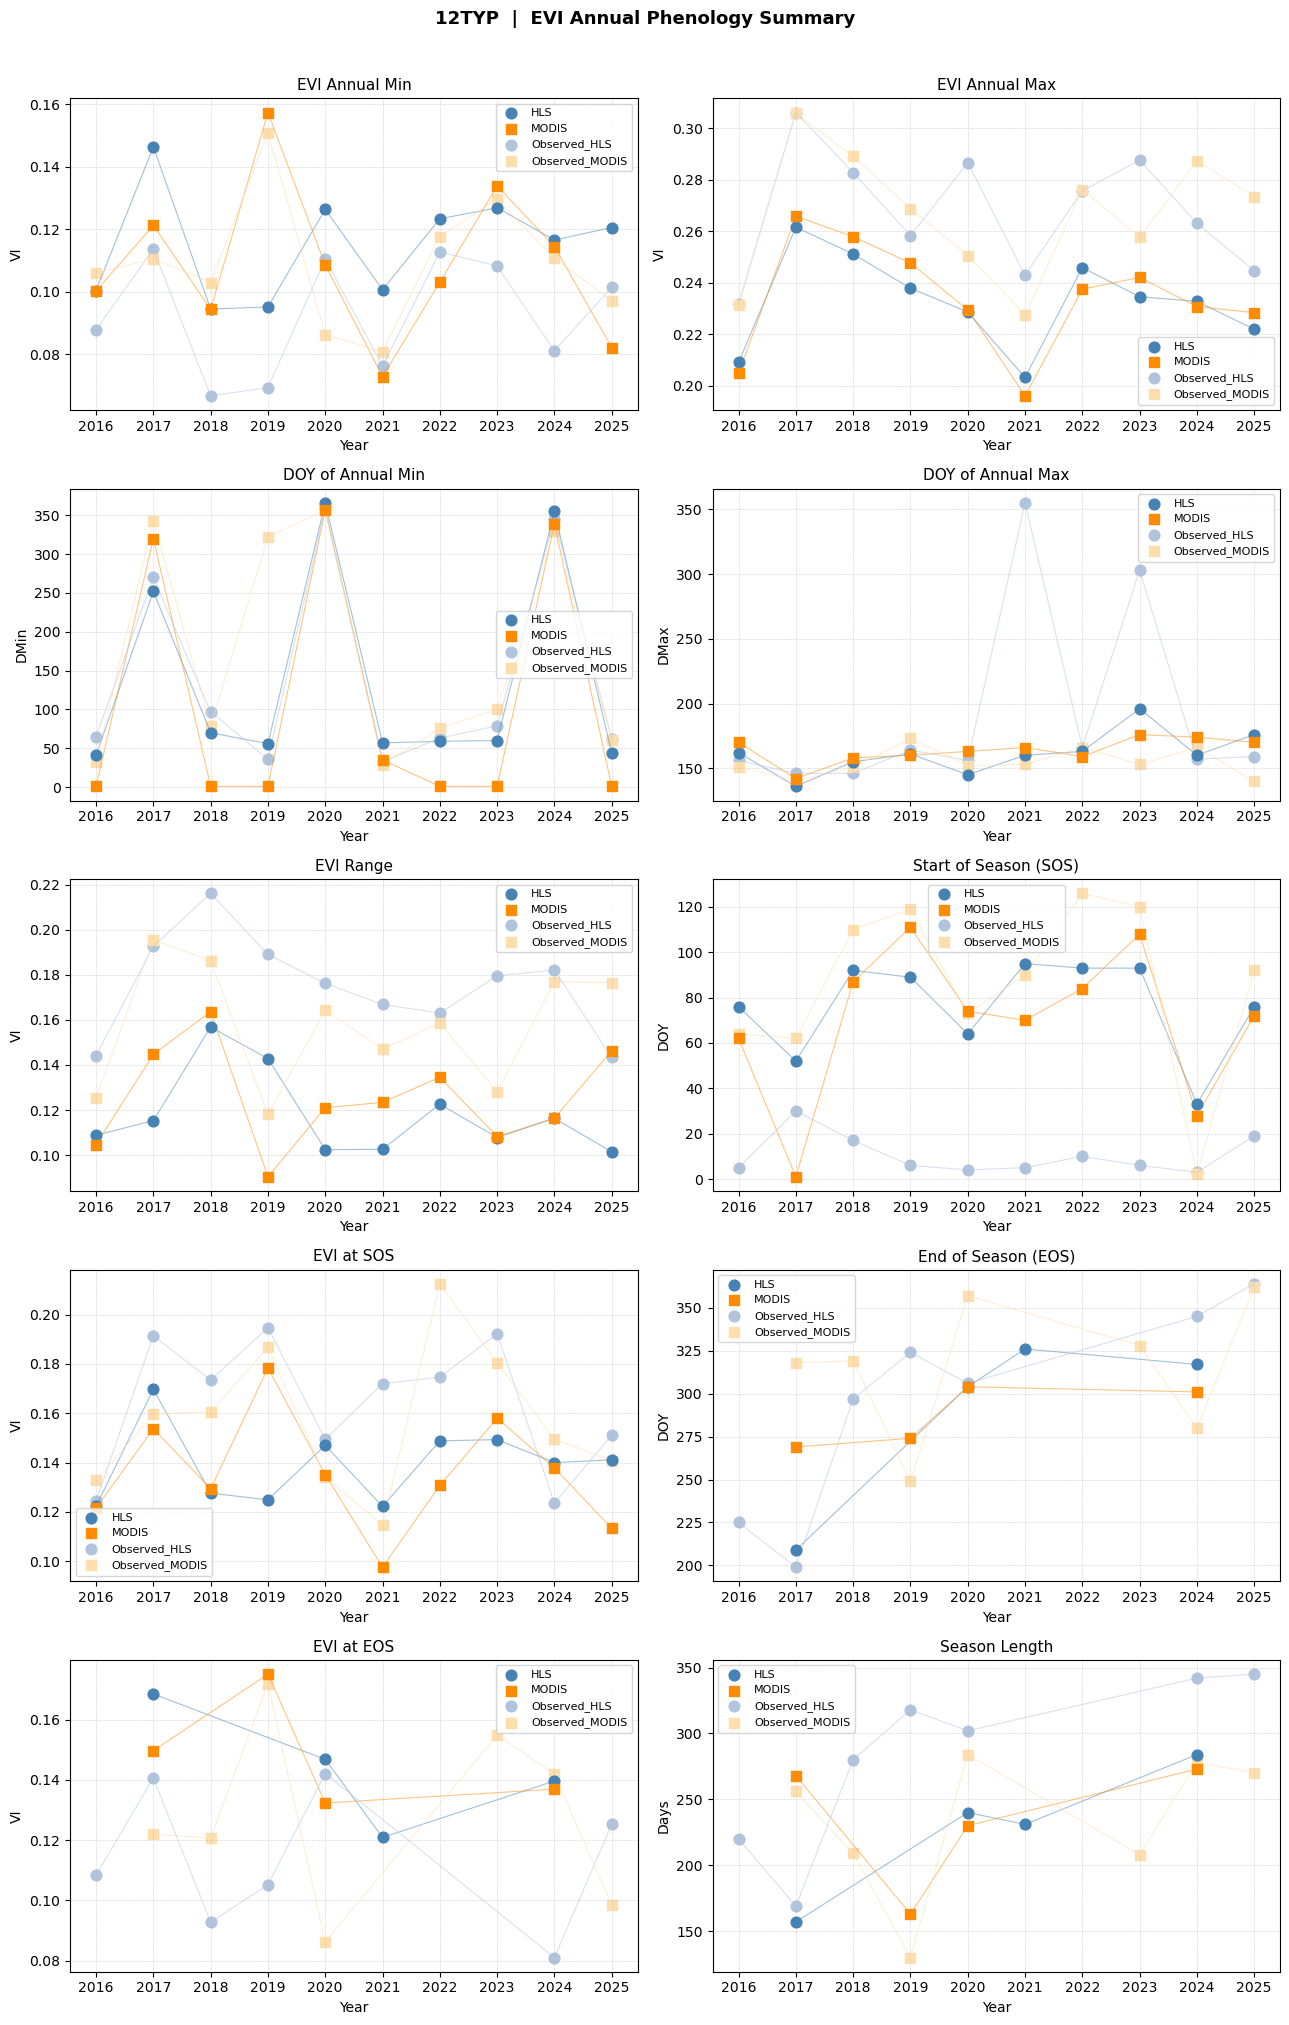

Plot saved: hls_modis_comparisons/12TYP/12TYP_EVI_annual_phenology_summary.png


In [89]:
summary_df = compute_annual_phenology_summary(
    hls, 
    modis, 
    veg_index, 
    output_dir,
    tile_id=tile_id,
    vi_min_filter=None,    
)

In [53]:
plot_vi_timeseries(hls, modis, veg_index, output_dir, tile_id=tile_id, vi_min=None)

NameError: name 'plot_vi_timeseries' is not defined

In [ ]:
plot_vi_correlation(hls, modis, veg_index, output_dir, tile_id=tile_id, vi_min=None)

In [ ]:
vi_peaks_troughs(hls, modis, veg_index, tile_id, stat="mean", vi_min=None)

In [ ]:
plot_vi_seasonal_mean(hls, modis, veg_index, output_dir, tile_id=tile_id, vi_min=None)